In [1]:
import os
from pathlib import Path

# Override GHIST_BUNDLE_ROOT when the downloaded bundle is stored elsewhere.
BUNDLE_ROOT = Path(os.getenv("GHIST_BUNDLE_ROOT") or "../bundle").expanduser()

CONFIG = {
    "gt": BUNDLE_ROOT / "evaluation_data/breast2/cell_gene_matrix_filtered.csv",
    "coordinates": BUNDLE_ROOT / "evaluation_data/breast2/cell_coords.csv",
    "labels": BUNDLE_ROOT / "evaluation_data/breast2/cell_type_filtered.csv",
    "within": {
        "GHIST+": BUNDLE_ROOT / "GHIST_plus/predictions/breast_single/trainval_slide3_pred_expr_scaled.csv",
        "GHIST": BUNDLE_ROOT / "other_models/within_slide/GHIST_pred_expr.csv",
        "SpatialEx": BUNDLE_ROOT / "other_models/within_slide/SpatialEx_pred_expr.csv",
    },
    "full": {
        "GHIST+": BUNDLE_ROOT / "GHIST_plus/predictions/breast_multi/test_slide3_pred_expr_scaled.csv",
        "GHIST": BUNDLE_ROOT / "other_models/across_slide/GHIST_pred_expr.csv",
        "SpatialEx": BUNDLE_ROOT / "other_models/across_slide/SpatialEx_pred_expr.csv",
        "Phoenix": BUNDLE_ROOT / "other_models/across_slide/Phoenix_pred_expr.csv",
    },
    "external": {
        "ATERA": {
            "prediction": BUNDLE_ROOT / "GHIST_plus/predictions/breast_multi/atera/test_slide9101_pred_expr_scaled.npz",
            "gt": BUNDLE_ROOT / "evaluation_data/atera/cell_gene_matrix_filtered.csv",
            "coordinates": BUNDLE_ROOT / "evaluation_data/atera/cell_coords.csv",
            "expected": (168335, 413, 403),
        },
        "Breast5K": {
            "prediction": BUNDLE_ROOT / "GHIST_plus/predictions/breast_multi/breast5k/test_slide6_pred_expr_scaled.npz",
            "gt": BUNDLE_ROOT / "evaluation_data/breast5k/cell_gene_matrix_filtered.csv",
            "coordinates": BUNDLE_ROOT / "evaluation_data/breast5k/cell_coords_histology_filtered.csv",
            "expected": (564723, 258, 258),
        },
    },
}

FULL_METHODS = ["GHIST+", "GHIST", "SpatialEx", "Phoenix"]
WITHIN_SCALES = {"GHIST+": 0.5, "GHIST": 1.0, "SpatialEx": 1.0}
FULL_SCALES = {"GHIST+": 1.0, "GHIST": 1.0, "SpatialEx": 1.0, "Phoenix": 1.0}
EXPECTED_COHORTS = {"within": (12719, 280), "full": (76779, 276)}

D_MARKERS = {
    "T": ["CD3E", "CD3G", "TRAC", "CD247"],
    "B": ["MS4A1", "CD79A", "CD79B", "BANK1", "CD19"],
    "Plasma": ["MZB1", "TNFRSF17", "PRDM1", "TENT5C"],
    "Macrophage": ["C1QA", "C1QC", "APOC1", "CD68", "CD163", "MRC1", "MMP12"],
    "Myeloid (excluding macrophage)": ["FCER1A", "CLEC9A", "LILRA4", "IL3RA", "CD14", "S100A8", "MNDA", "ITGAX"],
    "Stromal": ["LUM", "PDGFRA", "PDGFRB", "ACTA2", "MYH11", "DPT", "CCDC80", "POSTN", "LRRC15", "MMP2"],
    "Epithelial": ["EPCAM", "CDH1", "KRT8", "KRT7", "KRT5", "KRT14", "GATA3", "FOXA1", "AGR3", "PIGR"],
    "Malignant": ["ERBB2", "MKI67", "TOP2A", "CCND1", "APOBEC3B", "LYPD3", "S100A14", "TACSTD2"],
}

E_MARKERS = {
    "B": ["MS4A1", "CD79A", "CD79B", "BANK1"],
    "Epithelial": ["EPCAM", "CDH1", "KRT8", "KRT7", "KRT5", "KRT14"],
    "Macrophage": ["C1QA", "C1QC", "APOC1", "CD68", "CD163", "MRC1", "MMP12"],
    "Malignant": ["ERBB2", "MKI67", "TOP2A", "CCND1", "APOBEC3B", "LYPD3", "S100A14", "TACSTD2"],
    "Myeloid (excluding macrophage)": ["FCER1A", "CLEC9A", "LILRA4", "IL3RA", "CD14", "S100A8", "MNDA", "ITGAX"],
    "Plasma": ["MZB1", "TNFRSF17", "PRDM1", "TENT5C"],
    "Stromal": ["LUM", "PDGFRA", "PDGFRB", "ACTA2", "MYH11", "DPT", "CCDC80", "POSTN", "LRRC15", "MMP2"],
    "T": ["CD3E", "CD3G", "TRAC", "CD247", "IL7R", "LTB"],
}
E_CLASS_ORDER = [*E_MARKERS, "Unassigned"]

G_MARKERS = {
    "B": ["MS4A1", "CD79A", "CD79B", "BANK1"],
    "Epithelial": ["KRT5", "KRT14", "EPCAM"],
    "Macrophage": ["LYZ", "C1QA", "C1QC", "CD68", "FCER1G"],
    "Malignant": ["EPCAM", "KRT8", "ERBB2", "MKI67"],
    "Myeloid": ["FCER1A", "ITGAX", "LILRA4"],
    "Plasma": ["MZB1", "TNFRSF17"],
    "Stromal": ["ACTA2", "VWF", "PECAM1"],
    "T": ["CD3E", "TRAC", "IL7R", "LTB", "NKG7"],
}


In [2]:
import tempfile
import warnings
from dataclasses import dataclass

import numpy as np

warnings.filterwarnings("ignore", message="Pandas requires version")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")

import anndata as ad
import pyucell as uc

PYUCELL_VERSION = getattr(uc, "__version__", "unknown")
print(f"Using pyUCell {PYUCELL_VERSION}")

for name, value in [("int", int), ("float", float), ("bool", bool), ("object", object), ("complex", complex)]:
    if name not in np.__dict__:
        setattr(np, name, value)

import pandas as pd
from scipy.ndimage import gaussian_filter, uniform_filter
from scipy.spatial import cKDTree
from scipy.stats import rankdata

ID_COLUMNS = ["c_id", "cell_id", "cellID", "Cell ID", "id", "V1"]
NON_GENES = {"x", "y", "x_coord", "y_coord", "x coordinate", "y coordinate"}


def id_column(columns):
    columns = list(columns)
    return next((name for name in ID_COLUMNS if name in columns), columns[0])


def source_schema(path):
    path = Path(path)
    if path.suffix == ".npz":
        with np.load(path, allow_pickle=True) as archive:
            ids = archive["cell_ids"].astype(np.int64)
            genes = archive["gene_names"].astype(str).tolist()
    else:
        columns = pd.read_csv(path, nrows=0).columns.astype(str).str.strip().tolist()
        key = id_column(columns)
        ids = pd.to_numeric(pd.read_csv(path, usecols=[key])[key], errors="raise").to_numpy(np.int64)
        genes = [name for name in columns if name != key and name not in NON_GENES]
    if len(ids) != len(np.unique(ids)) or len(genes) != len(set(genes)):
        raise ValueError(f"Non-unique identifiers: {path}")
    return ids, genes


def load_matrix(path, ids, genes):
    path = Path(path)
    if path.suffix == ".npz":
        with np.load(path, allow_pickle=True) as archive:
            source_ids = archive["cell_ids"].astype(np.int64)
            source_genes = archive["gene_names"].astype(str)
            key = next(name for name in ["pred_expr_scaled", "expression", "predictions", "pred_expr"] if name in archive)
            values = archive[key]
        row_lookup = {value: index for index, value in enumerate(source_ids)}
        column_lookup = {value: index for index, value in enumerate(source_genes)}
        return values[np.ix_([row_lookup[value] for value in ids], [column_lookup[value] for value in genes])].astype(np.float64)
    columns = pd.read_csv(path, nrows=0).columns.astype(str).str.strip().tolist()
    key = id_column(columns)
    frame = pd.read_csv(path, usecols=[key, *genes])
    frame[key] = pd.to_numeric(frame[key], errors="raise").astype(np.int64)
    return frame.set_index(key).loc[ids, genes].to_numpy(np.float64)


def load_coordinates(path):
    frame = pd.read_csv(path)
    key = id_column(frame.columns)
    x = next(name for name in ["x_coord", "x", "x coordinate"] if name in frame)
    y = next(name for name in ["y_coord", "y", "y coordinate"] if name in frame)
    frame = frame.rename(columns={key: "Cell ID", x: "x", y: "y"})
    frame["Cell ID"] = pd.to_numeric(frame["Cell ID"], errors="raise").astype(np.int64)
    if frame["Cell ID"].duplicated().any():
        raise ValueError("Duplicate coordinate cell IDs")
    return frame.set_index("Cell ID")[["x", "y"]].astype(float)


def load_labels(path):
    frame = pd.read_csv(path, dtype=str)
    key = id_column(frame.columns)
    label = next(name for name in ["ct", "cell_type", "celltype", "label"] if name in frame)
    frame = frame.rename(columns={key: "Cell ID", label: "label"})
    frame["Cell ID"] = pd.to_numeric(frame["Cell ID"], errors="raise").astype(np.int64)
    if frame["Cell ID"].duplicated().any():
        raise ValueError("Duplicate label cell IDs")
    return frame.set_index("Cell ID")["label"].str.strip()


def load_scope(name, method_paths, scales):
    coordinates = load_coordinates(CONFIG["coordinates"])
    labels = load_labels(CONFIG["labels"]) if name == "full" else None
    paths = {"GT": CONFIG["gt"], **method_paths}
    schemas = {source: source_schema(path) for source, path in paths.items()}
    common_ids = set(coordinates.index)
    if labels is not None:
        common_ids &= set(labels.index)
    common_genes = None
    for ids, genes in schemas.values():
        common_ids &= set(ids)
        common_genes = set(genes) if common_genes is None else common_genes & set(genes)
    ids = np.asarray(sorted(common_ids), dtype=np.int64)
    genes = sorted(common_genes)
    if (len(ids), len(genes)) != EXPECTED_COHORTS[name]:
        raise AssertionError(f"{name} cohort is {(len(ids), len(genes))}, expected {EXPECTED_COHORTS[name]}")
    raw = load_matrix(CONFIG["gt"], ids, genes)
    predictions = {method: load_matrix(path, ids, genes) * scales[method] for method, path in method_paths.items()}
    if not np.isfinite(raw).all() or np.any(raw < 0):
        raise ValueError("Invalid raw GT")
    if any(not np.isfinite(values).all() for values in predictions.values()):
        raise ValueError("Invalid predictions")
    result = {
        "ids": ids,
        "genes": genes,
        "raw": raw,
        "gt": np.log1p(raw),
        "coordinates": coordinates.loc[ids],
        "labels": None if labels is None else labels.loc[ids],
        "predictions": predictions,
    }
    if labels is not None and set(result["labels"].unique()) != set(E_CLASS_ORDER):
        raise AssertionError("Unexpected full-cohort cell taxonomy")
    return result


def load_external_scope(name, spec):
    coordinates = load_coordinates(spec["coordinates"])
    pred_ids, pred_genes = source_schema(spec["prediction"])
    gt_ids, gt_genes = source_schema(spec["gt"])
    gt_gene_set = set(gt_genes)
    genes = [gene for gene in pred_genes if gene in gt_gene_set]
    ids = np.intersect1d(pred_ids, gt_ids, assume_unique=True)
    ids = np.intersect1d(ids, coordinates.index.to_numpy(np.int64), assume_unique=True)
    expected_cells, expected_genes, expected_valid = spec["expected"]
    if (len(ids), len(genes)) != (expected_cells, expected_genes):
        raise AssertionError(f"{name} cohort is {(len(ids), len(genes))}, expected {(expected_cells, expected_genes)}")
    raw = load_matrix(spec["gt"], ids, genes)
    prediction = load_matrix(spec["prediction"], ids, genes) * 0.5
    if not np.isfinite(raw).all() or np.any(raw < 0) or not np.isfinite(prediction).all():
        raise ValueError(f"Invalid external expression values: {name}")
    return {
        "name": name,
        "ids": ids,
        "genes": genes,
        "gt": np.log1p(raw),
        "prediction": prediction,
        "coordinates": coordinates.loc[ids],
        "expected_valid_pcc": expected_valid,
    }


def pearson(left, right):
    left = np.asarray(left, dtype=np.float64)
    right = np.asarray(right, dtype=np.float64)
    keep = np.isfinite(left) & np.isfinite(right)
    left = left[keep]
    right = right[keep]
    if left.size < 2:
        return np.nan
    left = left - left.mean()
    right = right - right.mean()
    denominator = np.sqrt(np.dot(left, left) * np.dot(right, right))
    return float(np.dot(left, right) / denominator) if denominator > 0 else np.nan


def pearson_per_gene(target, prediction):
    return np.asarray([pearson(target[:, index], prediction[:, index]) for index in range(target.shape[1])])


def finite_nonconstant_columns(*matrices):
    valid = np.ones(matrices[0].shape[1], dtype=bool)
    for matrix in matrices:
        valid &= np.isfinite(matrix).all(axis=0)
        valid &= matrix.std(axis=0) > 0
    return valid


def cmd_eq17(target, prediction, columns, epsilon=1e-12):
    target = target[:, columns]
    prediction = prediction[:, columns]
    if target.shape[1] < 2:
        return np.nan
    target_correlation = np.corrcoef(target, rowvar=False)
    prediction_correlation = np.corrcoef(prediction, rowvar=False)
    numerator = float(np.trace(prediction_correlation @ target_correlation))
    denominator = float(np.linalg.norm(prediction_correlation, "fro") * np.linalg.norm(target_correlation, "fro") + epsilon)
    return 1.0 - numerator / denominator


@dataclass(frozen=True)
class SsimGrid:
    height: int
    width: int
    flat_index: np.ndarray
    count: np.ndarray
    crop: tuple


def build_ssim_grid(x, y, width=400, minimum_height=20):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    height = max(minimum_height, int(round(width * (ymax - ymin) / (xmax - xmin))))
    xi = np.clip((((x - xmin) / (xmax - xmin)) * (width - 1)).astype(np.int32), 0, width - 1)
    yi = np.clip((((y - ymin) / (ymax - ymin)) * (height - 1)).astype(np.int32), 0, height - 1)
    flat_index = yi * width + xi
    count = np.bincount(flat_index, minlength=height * width).reshape(height, width).astype(np.float64)
    occupied_y, occupied_x = np.where(count > 0)
    crop = (slice(int(occupied_y.min()), int(occupied_y.max()) + 1), slice(int(occupied_x.min()), int(occupied_x.max()) + 1))
    return SsimGrid(height, width, flat_index, count, crop)


def ssim_spatial_map(values, grid, sigma=1.0):
    sums = np.bincount(grid.flat_index, weights=np.asarray(values, dtype=np.float64), minlength=grid.height * grid.width).reshape(grid.height, grid.width)
    mean_map = np.divide(sums, grid.count, out=np.zeros_like(sums), where=grid.count > 0)
    return gaussian_filter(mean_map, sigma=sigma, mode="nearest", truncate=4.0)[grid.crop]


def ssim_local(target_map, prediction_map, data_range, window=7, k1=0.01, k2=0.03):
    if not np.isfinite(data_range) or data_range <= 0:
        return np.nan
    arguments = {"size": window, "mode": "reflect", "origin": 0}
    mean_target = uniform_filter(target_map, **arguments)
    mean_prediction = uniform_filter(prediction_map, **arguments)
    mean_target_sq = uniform_filter(target_map * target_map, **arguments)
    mean_prediction_sq = uniform_filter(prediction_map * prediction_map, **arguments)
    mean_cross = uniform_filter(target_map * prediction_map, **arguments)
    sample_factor = window ** 2 / (window ** 2 - 1.0)
    variance_target = sample_factor * (mean_target_sq - mean_target ** 2)
    variance_prediction = sample_factor * (mean_prediction_sq - mean_prediction ** 2)
    covariance = sample_factor * (mean_cross - mean_target * mean_prediction)
    c1 = (k1 * data_range) ** 2
    c2 = (k2 * data_range) ** 2
    numerator = (2 * mean_target * mean_prediction + c1) * (2 * covariance + c2)
    denominator = (mean_target ** 2 + mean_prediction ** 2 + c1) * (variance_target + variance_prediction + c2)
    score_map = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator != 0)
    border = (window - 1) // 2
    interior = score_map[border:-border, border:-border]
    return float(np.mean(interior)) if np.isfinite(interior).all() else np.nan


def binary_auroc(labels, scores):
    labels = np.asarray(labels, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float64)
    keep = np.isfinite(scores)
    labels = labels[keep]
    scores = scores[keep]
    positives = int(labels.sum())
    negatives = int(labels.size - positives)
    if positives == 0 or negatives == 0:
        return np.nan
    ranks = rankdata(scores, method="average")
    return float((ranks[labels == 1].sum() - positives * (positives + 1) / 2) / (positives * negatives))


def rank_marker_scores(expression, genes, signatures):
    gene_index = {gene: index for index, gene in enumerate(genes)}
    output = {}
    for name, requested in signatures.items():
        indices = [gene_index[gene] for gene in requested]
        ranks = pd.DataFrame(expression[:, indices]).rank(axis=0, method="average", pct=True)
        output[name] = ranks.mean(axis=1).to_numpy(np.float64)
    return pd.DataFrame(output)


def density_map(coordinates, mask, xbins, ybins, sigma=1.2):
    points = coordinates.loc[mask.index[mask], ["y", "x"]]
    density = np.histogram2d(points["y"], points["x"], bins=[ybins, xbins])[0]
    density = gaussian_filter(density.astype(float), sigma=sigma)
    if density.sum() > 0:
        density /= density.sum()
    return density


def density_iou(left, right):
    union = np.maximum(left, right).sum()
    return float(np.minimum(left, right).sum() / union) if union > 0 else np.nan


def giotto_scores(expression, coordinates, k=8):
    neighbours = cKDTree(coordinates).query(coordinates, k=k + 1)[1][:, 1:]
    scores = np.zeros(expression.shape[1], dtype=np.float32)
    for index in range(expression.shape[1]):
        ranks = rankdata(expression[:, index], method="average").astype(np.float32)
        near = ranks[neighbours].mean(axis=1)
        ranks -= ranks.mean()
        near -= near.mean()
        denominator = np.sqrt(np.dot(ranks, ranks) * np.dot(near, near))
        if denominator > 0:
            scores[index] = np.dot(ranks, near) / denominator
    return scores


def ranks_from_order(order):
    ranks = np.empty(len(order), dtype=int)
    ranks[order] = np.arange(1, len(order) + 1)
    return ranks


def hvg_scores(raw, bins=20):
    mean = raw.mean(axis=0)
    variance = raw.var(axis=0, ddof=1)
    dispersion = np.divide(variance, mean, out=np.zeros_like(variance), where=mean > 0)
    table = pd.DataFrame({"mean_log": np.log1p(mean), "disp_log": np.log1p(dispersion)})
    table["bin"] = pd.cut(table["mean_log"], bins=bins)
    statistics = table.groupby("bin", observed=False)["disp_log"].agg(["mean", "std"])
    table = table.join(statistics, on="bin")
    return ((table["disp_log"] - table["mean"]) / table["std"]).replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(np.float32)


Using pyUCell 0.5.0


In [3]:
def spatial_metadata(data):
    scores = giotto_scores(data["gt"].astype(np.float32), data["coordinates"][["x", "y"]].to_numpy(np.float32))
    return {
        "scores": scores,
        "svg": ranks_from_order(np.argsort(-scores, kind="stable")),
        "non_svg": ranks_from_order(np.argsort(np.abs(scores), kind="stable")),
    }


def calculate_gene_pcc(data, metadata):
    table = pd.DataFrame({"Gene": data["genes"], "GT Giotto spatial score": metadata["scores"], "SVG rank": metadata["svg"], "Non-SVG rank": metadata["non_svg"]})
    for method, prediction in data["predictions"].items():
        table[f"{method} PCC"] = pearson_per_gene(data["gt"], prediction)
    return table.sort_values("SVG rank", kind="stable")


def calculate_2b(data, metadata):
    hvg = hvg_scores(data["raw"])
    table = pd.DataFrame({"Gene": data["genes"], "GT Giotto spatial score": metadata["scores"], "SVG rank": metadata["svg"], "GT Seurat HVG score": hvg, "HVG rank": ranks_from_order(np.argsort(-hvg, kind="stable"))})
    grid = build_ssim_grid(data["coordinates"]["x"], data["coordinates"]["y"], width=400)
    values = {method: np.full(len(data["genes"]), np.nan) for method in data["predictions"]}
    for index in range(len(data["genes"])):
        target = ssim_spatial_map(data["gt"][:, index], grid, sigma=1.0)
        data_range = float(np.ptp(target))
        for method, prediction in data["predictions"].items():
            candidate = ssim_spatial_map(prediction[:, index], grid, sigma=1.0)
            values[method][index] = ssim_local(target, candidate, data_range, window=7, k1=0.01, k2=0.03)
    for method, scores in values.items():
        table[f"{method} SSIM"] = scores
    return table.sort_values("SVG rank", kind="stable")


def calculate_2d(data, predictions):
    assigned = data["labels"].ne("Unassigned").to_numpy()
    labels = data["labels"].iloc[np.flatnonzero(assigned)]
    scores = {method: rank_marker_scores(prediction[assigned], data["genes"], D_MARKERS) for method, prediction in predictions.items()}
    rows = []
    for cell_type, genes in D_MARKERS.items():
        for method in FULL_METHODS:
            rows.append({"Marker set": cell_type, "Model": method, "AUROC": binary_auroc(labels.eq(cell_type).to_numpy(int), scores[method][cell_type]), "Positive GT cell types": cell_type, "Marker genes used": ", ".join(genes)})
    return pd.DataFrame(rows)


def calculate_ucell_by_source(data, predictions):
    gene_set = set(data["genes"])
    missing_markers = {
        name: [gene for gene in requested if gene not in gene_set]
        for name, requested in E_MARKERS.items()
    }
    missing_markers = {name: genes for name, genes in missing_markers.items() if genes}
    if missing_markers:
        raise ValueError(f"Figure 2e markers missing from the shared panel: {missing_markers}")

    max_rank = min(1500, len(data["genes"]))
    output = {}
    for source, expression in predictions.items():
        adata = ad.AnnData(
            X=np.asarray(expression, dtype=np.float32),
            obs=pd.DataFrame(index=data["ids"].astype(str)),
            var=pd.DataFrame(index=pd.Index(data["genes"], dtype=str)),
        )
        uc.compute_ucell_scores(
            adata,
            signatures=E_MARKERS,
            max_rank=max_rank,
            missing_genes="skip",
            chunk_size=500,
            suffix="_UCell",
            n_jobs=1,
        )
        scores = pd.DataFrame(
            {
                name: adata.obs[f"{name}_UCell"].to_numpy(dtype=np.float64)
                for name in E_MARKERS
            },
            index=data["ids"],
        )
        scores["Unassigned"] = 1.0 - scores[list(E_MARKERS)].max(axis=1)
        output[source] = scores
    return output


def calculate_2e(data, ucell_by_source):
    coordinates = data["coordinates"]
    xbins = np.arange(coordinates["x"].min(), coordinates["x"].max() + 150.0, 150.0)
    ybins = np.arange(coordinates["y"].min(), coordinates["y"].max() + 150.0, 150.0)
    rows = []
    for cell_type in E_CLASS_ORDER:
        truth_mask = data["labels"].eq(cell_type)
        count = int(truth_mask.sum())
        truth = density_map(coordinates, truth_mask, xbins, ybins, sigma=1.2)
        for source in FULL_METHODS:
            scores = ucell_by_source[source]
            selected = scores[cell_type].nlargest(count, keep="first").index
            prediction_mask = pd.Series(False, index=scores.index)
            prediction_mask.loc[selected] = True
            prediction = density_map(coordinates, prediction_mask, xbins, ybins, sigma=1.2)
            rows.append({"Class": cell_type, "Source": source, "Spatial IoU": density_iou(truth, prediction)})
    return pd.DataFrame(rows)


def calculate_2f(data, metadata):
    predictions = data["predictions"]
    valid = finite_nonconstant_columns(data["gt"], *predictions.values())
    subsets = {
        "All genes": np.arange(len(data["genes"])),
        "Top 20 SVGs": np.flatnonzero(metadata["svg"] <= 20),
        "Top 50 SVGs": np.flatnonzero(metadata["svg"] <= 50),
        "Top 20 non-SVGs": np.flatnonzero(metadata["non_svg"] <= 20),
        "Top 50 non-SVGs": np.flatnonzero(metadata["non_svg"] <= 50),
    }
    rows = []
    for name, requested in subsets.items():
        retained = requested[valid[requested]]
        row = {"Gene subset": name, "Gene count": len(retained), "Requested gene count": len(requested), "Cell count": len(data["ids"])}
        for method, prediction in predictions.items():
            row[f"{method} CMD"] = cmd_eq17(data["gt"], prediction, retained)
        rows.append(row)
    return pd.DataFrame(rows)


def winner_take_all(expression, ids, genes, unassigned_fraction):
    ranks = pd.DataFrame(expression, index=ids, columns=genes).rank(axis=0, method="average", pct=True)
    scores = pd.DataFrame(index=ids)
    for cell_type, markers in G_MARKERS.items():
        scores[cell_type] = ranks[markers].mean(axis=1)
    labels = scores.idxmax(axis=1)
    top_score = scores.max(axis=1)
    labels[top_score <= top_score.quantile(unassigned_fraction)] = "Unassigned"
    return labels


def calculate_2g(data, predictions):
    coordinates = data["coordinates"].rename(columns={"x": "x coordinate", "y": "y coordinate"})
    truth = data["labels"].replace({"Myeloid (excluding macrophage)": "Myeloid"})
    unassigned_fraction = float(truth.eq("Unassigned").mean())
    labels = {"Original": truth}
    for method in FULL_METHODS:
        labels[method] = winner_take_all(predictions[method], data["ids"], data["genes"], unassigned_fraction)
    panels = []
    for model, cell_types in labels.items():
        frame = coordinates.copy()
        frame["Original GT cell type"] = truth
        frame["Cell type label"] = cell_types
        frame["Model"] = model
        frame.index.name = "Cell ID"
        panels.append(frame.reset_index())
    return pd.concat(panels, ignore_index=True)


def calculate_external_pcc(data):
    pcc = pearson_per_gene(data["gt"], data["prediction"])
    valid = int(np.isfinite(pcc).sum())
    if valid != data["expected_valid_pcc"]:
        raise AssertionError(f"{data['name']} valid PCC count is {valid}, expected {data['expected_valid_pcc']}")
    svg = spatial_metadata(data)["svg"]
    n_cells = len(data["ids"])
    return pd.DataFrame({
        "Dataset": data["name"], "Method": "GHIST+", "gene": data["genes"],
        "PCC": pcc, "SVG_rank": svg, "PCC_n": n_cells, "SVG_rank_n": n_cells,
        "PCC_unit": "unique matched cells",
        "SVG_rank_scope": "GT-only Giotto rank on the same unique-cell cohort",
    })


In [4]:
temporary_directory = tempfile.TemporaryDirectory(prefix="figure2_notebook_")
WORK = Path(temporary_directory.name)
os.environ["FIG2_TEMP"] = str(WORK)

within = load_scope("within", CONFIG["within"], WITHIN_SCALES)
full = load_scope("full", CONFIG["full"], FULL_SCALES)
within_metadata = spatial_metadata(within)
full_metadata = spatial_metadata(full)
full_predictions = full["predictions"]
ucell_by_source = calculate_ucell_by_source(full, full_predictions)

tables = {
    "2a": calculate_gene_pcc(within, within_metadata),
    "2b": calculate_2b(within, within_metadata),
    "2c": calculate_gene_pcc(full, full_metadata),
    "2d": calculate_2d(full, full_predictions),
    "2e": calculate_2e(full, ucell_by_source),
    "2f": calculate_2f(full, full_metadata),
    "2g": calculate_2g(full, full_predictions),
}

del within, full, within_metadata, full_metadata, full_predictions, ucell_by_source

for panel, dataset in (("2h", "ATERA"), ("2i", "Breast5K")):
    external = load_external_scope(dataset, CONFIG["external"][dataset])
    tables[panel] = calculate_external_pcc(external)
    del external

for panel, table in tables.items():
    table.to_csv(WORK / f"{panel}.csv", index=False)


In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

METHODS_WITHIN = ["GHIST+", "GHIST", "SpatialEx"]
METHODS_FULL = ["GHIST+", "GHIST", "SpatialEx", "Phoenix"]
COLOURS = {
    "GHIST+": "#D1495B",
    "GHIST": "#EDAE49",
    "SpatialEx": "#4C8DB8",
    "Phoenix": "#2A9D8F",
}
DISPLAY_CELL_TYPE = {"Myeloid (excluding macrophage)": "Myeloid"}

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans", "sans-serif"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#333333",
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})


def style_axis(axis):
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color("#333333")
        spine.set_linewidth(0.7)
    axis.tick_params(direction="out", width=0.7, length=4, colors="#333333")


def facet_strip(axis, label):
    axis.add_patch(Rectangle(
        (0, 1.0), 1, 0.095,
        transform=axis.transAxes,
        facecolor="white",
        edgecolor="#333333",
        linewidth=0.7,
        clip_on=False,
        zorder=5,
    ))
    axis.text(
        0.5, 1.0475, label,
        transform=axis.transAxes,
        ha="center", va="center",
        fontweight="bold", zorder=6,
    )


def save_panel(figure, panel, size):
    figure.set_size_inches(*size)
    figure.savefig(
        WORK / f"{panel}.png",
        dpi=180,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(figure)


def add_method_legend(figure, methods, anchor=(0.985, 0.5)):
    handles = [
        Patch(
            facecolor=COLOURS[method],
            edgecolor="#333333",
            linewidth=0.8,
            label=method,
        )
        for method in methods
    ]
    figure.legend(
        handles=handles,
        loc="center right",
        bbox_to_anchor=anchor,
    )


def draw_boxplots(axis, groups, methods, value_getter):
    centers = np.arange(len(groups), dtype=float)
    total_width = 0.78
    box_width = total_width / len(methods) * 0.82
    offsets = (
        np.arange(len(methods)) - (len(methods) - 1) / 2
    ) * (total_width / len(methods))
    for offset, method in zip(offsets, methods):
        values = [
            np.asarray(value_getter(group, method), dtype=float)
            for group in groups
        ]
        values = [value[np.isfinite(value)] for value in values]
        if any(value.size == 0 for value in values):
            raise ValueError(f"Empty boxplot group for {method}")
        artists = axis.boxplot(
            values,
            positions=centers + offset,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            whis=1.5,
            showfliers=True,
            showcaps=False,
            boxprops={"edgecolor": "#333333", "linewidth": 1.0},
            medianprops={"color": "#333333", "linewidth": 1.2},
            whiskerprops={"color": "#333333", "linewidth": 1.0},
            flierprops={
                "marker": "o",
                "markersize": 3.2,
                "markerfacecolor": "#333333",
                "markeredgewidth": 0,
            },
        )
        for box in artists["boxes"]:
            box.set_facecolor(COLOURS[method])
    axis.set_xticks(centers, groups, rotation=60, ha="right")
    axis.set_xlim(-0.6, len(groups) - 0.4)
    style_axis(axis)


def plot_metric_boxes(data, methods, suffix, facets, ylim=None):
    figure, axes = plt.subplots(
        1,
        len(facets),
        sharey=True,
        figsize=(7, 4),
    )
    axes = np.atleast_1d(axes)
    groups = ["Top 20", "Top 50"]
    all_values = []
    for axis, (facet_label, rank_column) in zip(axes, facets):
        def values_for(group, method):
            top_k = int(group.split()[-1])
            values = data.loc[
                data[rank_column].le(top_k),
                f"{method} {suffix}",
            ].to_numpy(float)
            all_values.extend(values[np.isfinite(values)])
            return values

        draw_boxplots(axis, groups, methods, values_for)
        facet_strip(axis, facet_label)
        axis.set_xlabel("")

    if ylim is None:
        lower = min(all_values) if all_values else 0.0
        ylim = (lower - 0.03, 1.02)
    for axis in axes:
        axis.set_ylim(*ylim)
    axes[0].set_ylabel(suffix)
    for axis in axes[1:]:
        axis.tick_params(axis="y", left=False, labelleft=False)
    add_method_legend(figure, methods)
    figure.subplots_adjust(
        left=0.10,
        right=0.78,
        bottom=0.25,
        top=0.84,
        wspace=0.04,
    )
    return figure


def ordered_cell_types():
    original = tables["2g"].loc[
        tables["2g"]["Model"].eq("Original")
        & tables["2g"]["Cell type label"].ne("Unassigned"),
        "Cell type label",
    ]
    display_order = original.value_counts(sort=True).index.tolist()
    return [
        "Myeloid (excluding macrophage)"
        if label == "Myeloid"
        else label
        for label in display_order
    ]


CELL_TYPE_ORDER = ordered_cell_types()


def grouped_cell_type_bars(
    data,
    category_column,
    value_column,
    method_column,
    ylabel,
):
    observed = set(data[category_column].astype(str))
    expected = set(CELL_TYPE_ORDER)
    if observed != expected:
        raise ValueError(
            f"{category_column} taxonomy mismatch: "
            f"missing={sorted(expected - observed)}, "
            f"extra={sorted(observed - expected)}"
        )

    figure, axis = plt.subplots(figsize=(12, 5))
    centers = np.arange(len(CELL_TYPE_ORDER), dtype=float)
    width = 0.72 / len(METHODS_FULL)
    offsets = (
        np.arange(len(METHODS_FULL))
        - (len(METHODS_FULL) - 1) / 2
    ) * width

    for offset, method in zip(offsets, METHODS_FULL):
        indexed = (
            data.loc[data[method_column].eq(method)]
            .set_index(category_column)
            .reindex(CELL_TYPE_ORDER)
        )
        values = indexed[value_column].to_numpy(float)
        if not np.isfinite(values).all():
            raise ValueError(f"Undefined {ylabel} values for {method}")
        bars = axis.bar(
            centers + offset,
            values,
            width * 0.88,
            color=COLOURS[method],
            edgecolor="none",
            label=method,
        )
        for bar, value in zip(bars, values):
            axis.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.012,
                f"{value:.2f}".rstrip("0").rstrip("."),
                ha="center",
                va="bottom",
                fontsize=8,
            )

    labels = [
        DISPLAY_CELL_TYPE.get(label, label)
        for label in CELL_TYPE_ORDER
    ]
    axis.set_xticks(centers, labels, rotation=60, ha="right")
    axis.set_xlim(-0.6, len(centers) - 0.4)
    axis.set_ylim(0, 1.05)
    axis.set_yticks(np.arange(0, 1.01, 0.25))
    axis.set_ylabel(ylabel)
    style_axis(axis)
    add_method_legend(figure, METHODS_FULL)
    figure.subplots_adjust(
        left=0.08,
        right=0.86,
        bottom=0.30,
        top=0.96,
    )
    return figure


def plot_cmd(data):
    figure, axes = plt.subplots(
        1,
        2,
        sharey=True,
        figsize=(7, 4),
    )
    groups = ["Top 20", "Top 50"]

    for axis, gene_type in zip(axes, ["SVGs", "Non-SVGs"]):
        centers = np.arange(len(groups), dtype=float)
        width = 0.72 / len(METHODS_FULL)
        offsets = (
            np.arange(len(METHODS_FULL))
            - (len(METHODS_FULL) - 1) / 2
        ) * width
        tick_labels = []

        for group in groups:
            subset_name = f"{group} {'SVGs' if gene_type == 'SVGs' else 'non-SVGs'}"
            row = data.loc[data["Gene subset"].eq(subset_name)]
            if len(row) != 1:
                raise ValueError(f"Expected one CMD row for {subset_name}")
            retained = int(row["Gene count"].iloc[0])
            requested = int(row["Requested gene count"].iloc[0])
            if not 2 <= retained <= requested:
                raise ValueError(f"Invalid CMD coverage for {subset_name}")
            tick_labels.append(f"{group}\n(n={retained})")

        for offset, method in zip(offsets, METHODS_FULL):
            values = []
            for group in groups:
                subset_name = f"{group} {'SVGs' if gene_type == 'SVGs' else 'non-SVGs'}"
                row = data.loc[data["Gene subset"].eq(subset_name)]
                value = float(row[f"{method} CMD"].iloc[0])
                if not np.isfinite(value):
                    raise ValueError(
                        f"Undefined CMD for {method}, {subset_name}"
                    )
                values.append(value)
            bars = axis.bar(
                centers + offset,
                values,
                width * 0.88,
                color=COLOURS[method],
                edgecolor="none",
            )
            for bar, value in zip(bars, values):
                axis.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + 0.012,
                    f"{value:.3f}".rstrip("0").rstrip("."),
                    ha="center",
                    va="bottom",
                    fontsize=6.5,
                )

        axis.set_xticks(
            centers,
            tick_labels,
            rotation=60,
            ha="right",
        )
        axis.set_ylim(0, 1.05)
        axis.set_yticks(np.arange(0, 1.01, 0.25))
        facet_strip(axis, gene_type)
        style_axis(axis)

    axes[0].set_ylabel("Correlation matrix distance")
    axes[1].tick_params(axis="y", left=False, labelleft=False)
    add_method_legend(figure, METHODS_FULL)
    figure.subplots_adjust(
        left=0.11,
        right=0.78,
        bottom=0.29,
        top=0.84,
        wspace=0.04,
    )
    return figure


def plot_cell_type_maps(data):
    model_order = ["Original", *METHODS_FULL]
    original = data.loc[
        data["Model"].eq("Original"),
        "Cell type label",
    ]
    cell_type_order = original.value_counts(sort=True).index.tolist()
    if set(data["Model"]) != set(model_order):
        raise ValueError(
            "Figure 2g model labels do not match the expected models"
        )

    top_three = cell_type_order[:3]
    palette = dict(zip(
        top_three,
        ["#EDA04B", "#59A14F", "#4C8DB8"],
    ))
    other = sorted(
        set(data["Cell type label"]) - set(top_three)
    )
    other_colours = [
        "#D1495B",
        "#B07AA1",
        "#76B7B2",
        "#EDC948",
        "#9C755F",
        "#A7A7A7",
    ]
    if len(other) > len(other_colours):
        raise ValueError(
            "Figure 2g has more cell types than available colours"
        )
    palette.update(dict(zip(other, other_colours)))

    figure, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    x_limits = (
        float(data["x coordinate"].min()),
        float(data["x coordinate"].max()),
    )
    y_limits = (
        float(data["y coordinate"].max()),
        float(data["y coordinate"].min()),
    )

    for axis, model in zip(axes, model_order):
        panel = data.loc[data["Model"].eq(model)]
        if panel.empty:
            raise ValueError(f"Missing Figure 2g panel for {model}")
        for cell_type in cell_type_order:
            points = panel.loc[
                panel["Cell type label"].eq(cell_type)
            ]
            axis.scatter(
                points["x coordinate"],
                points["y coordinate"],
                s=0.45,
                c=palette[cell_type],
                linewidths=0,
                alpha=0.85,
                rasterized=True,
            )
        axis.set_xlim(*x_limits)
        axis.set_ylim(*y_limits)
        axis.set_aspect("equal", adjustable="box")
        axis.set_xticks([])
        axis.set_yticks([])
        facet_strip(axis, model)
        style_axis(axis)

    for axis in axes[len(model_order):]:
        axis.axis("off")

    handles = [
        Patch(
            facecolor=palette[label],
            edgecolor="none",
            label=label,
        )
        for label in cell_type_order
    ]
    legend_axis = axes[-1]
    legend_axis.legend(handles=handles, loc="center", frameon=False)
    legend_axis.axis("off")
    figure.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.05,
        top=0.94,
        wspace=0.04,
        hspace=0.12,
    )
    return figure


def plot_external(data, dataset_name):
    groups = ["All genes", "Top 20 SVGs", "Top 50 SVGs"]
    values = [
        data["PCC"].to_numpy(float),
        data.loc[data["SVG_rank"].le(20), "PCC"].to_numpy(float),
        data.loc[data["SVG_rank"].le(50), "PCC"].to_numpy(float),
    ]
    values = [value[np.isfinite(value)] for value in values]
    if any(value.size == 0 for value in values):
        raise ValueError(
            f"{dataset_name}: an external PCC group is empty"
        )

    figure, axis = plt.subplots(figsize=(4, 4))
    artists = axis.boxplot(
        values,
        positions=np.arange(3),
        widths=0.55,
        patch_artist=True,
        manage_ticks=False,
        whis=1.5,
        showfliers=True,
        showcaps=False,
        boxprops={"edgecolor": "#333333", "linewidth": 1.0},
        medianprops={"color": "#333333", "linewidth": 1.2},
        whiskerprops={"color": "#333333", "linewidth": 1.0},
        flierprops={
            "marker": "o",
            "markersize": 3.2,
            "markerfacecolor": "#333333",
            "markeredgewidth": 0,
        },
    )
    for box in artists["boxes"]:
        box.set_facecolor(COLOURS["GHIST+"])
    axis.set_xticks(
        np.arange(3),
        groups,
        rotation=45,
        ha="right",
    )
    axis.set_ylim(-0.22, 1.02)
    axis.set_ylabel("PCC")
    axis.set_title(dataset_name)
    style_axis(axis)
    figure.subplots_adjust(
        left=0.18,
        right=0.97,
        bottom=0.28,
        top=0.90,
    )
    return figure


figures = {
    "2a": (
        plot_metric_boxes(
            tables["2a"],
            METHODS_WITHIN,
            "PCC",
            [
                ("SVGs", "SVG rank"),
                ("Non-SVGs", "Non-SVG rank"),
            ],
        ),
        (7, 4),
    ),
    "2b": (
        plot_metric_boxes(
            tables["2b"],
            METHODS_WITHIN,
            "SSIM",
            [
                ("SVGs", "SVG rank"),
                ("HVGs", "HVG rank"),
            ],
            ylim=(0, 1.02),
        ),
        (7, 4),
    ),
    "2c": (
        plot_metric_boxes(
            tables["2c"],
            METHODS_FULL,
            "PCC",
            [
                ("SVGs", "SVG rank"),
                ("Non-SVGs", "Non-SVG rank"),
            ],
        ),
        (7, 4),
    ),
    "2d": (
        grouped_cell_type_bars(
            tables["2d"],
            "Marker set",
            "AUROC",
            "Model",
            "AUC",
        ),
        (12, 5),
    ),
    "2e": (
        grouped_cell_type_bars(
            tables["2e"].loc[
                tables["2e"]["Class"].ne("Unassigned")
            ],
            "Class",
            "Spatial IoU",
            "Source",
            "Spatial IoU",
        ),
        (12, 5),
    ),
    "2f": (plot_cmd(tables["2f"]), (7, 4)),
    "2g": (plot_cell_type_maps(tables["2g"]), (12, 8)),
    "2h": (plot_external(tables["2h"], "ATERA"), (4, 4)),
    "2i": (plot_external(tables["2i"], "Breast5K"), (4, 4)),
}

for panel, (figure, size) in figures.items():
    save_panel(figure, panel, size)


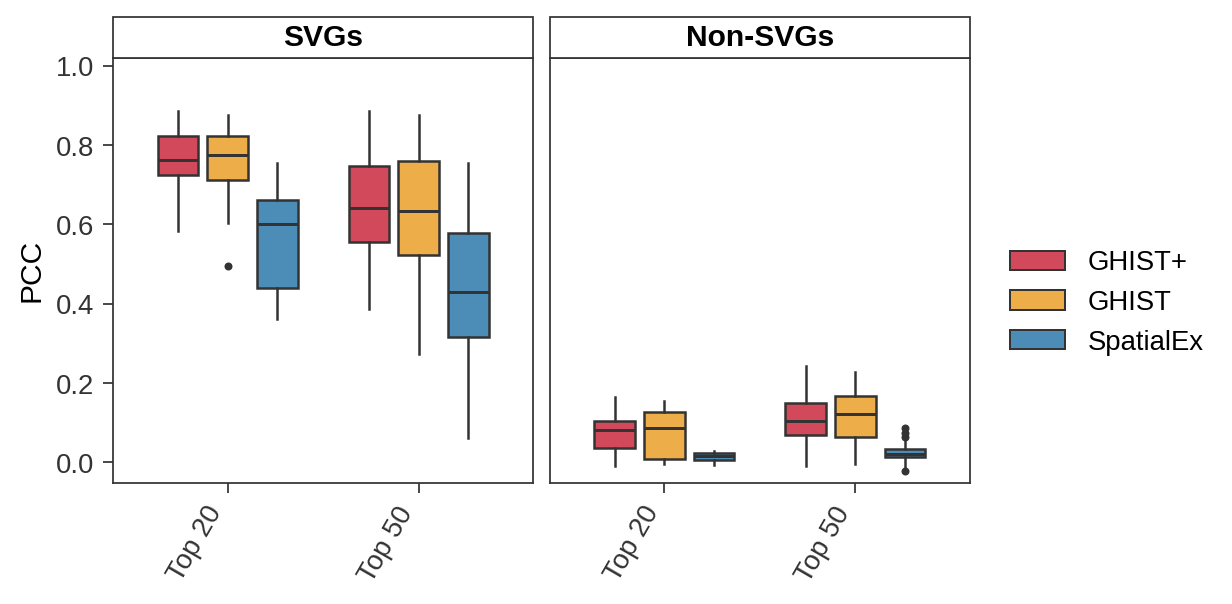

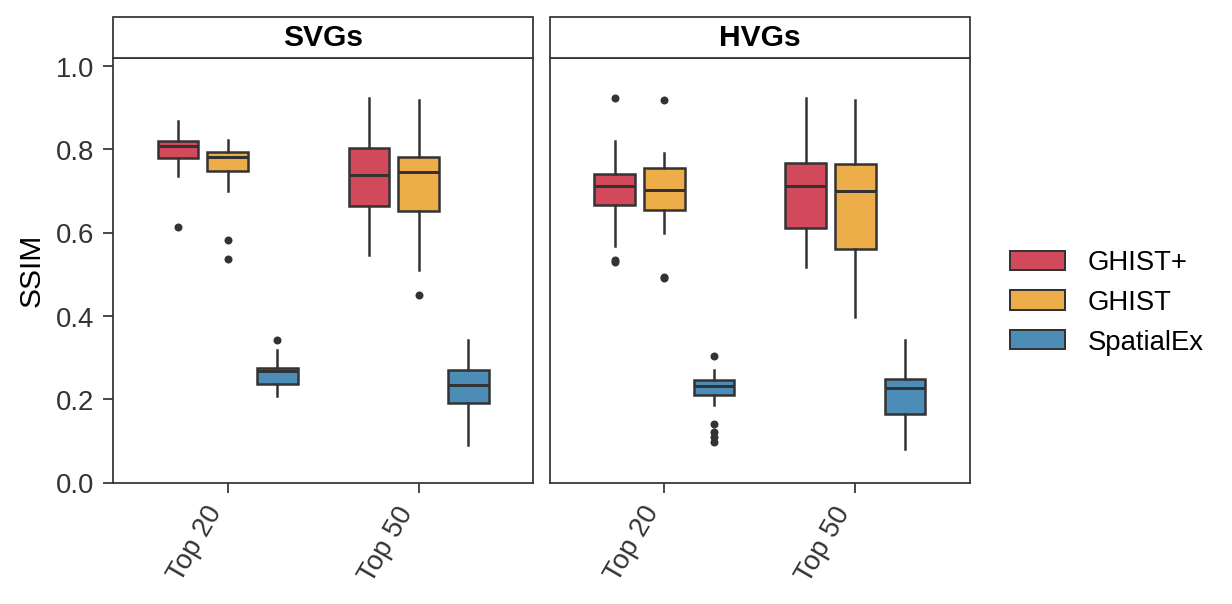

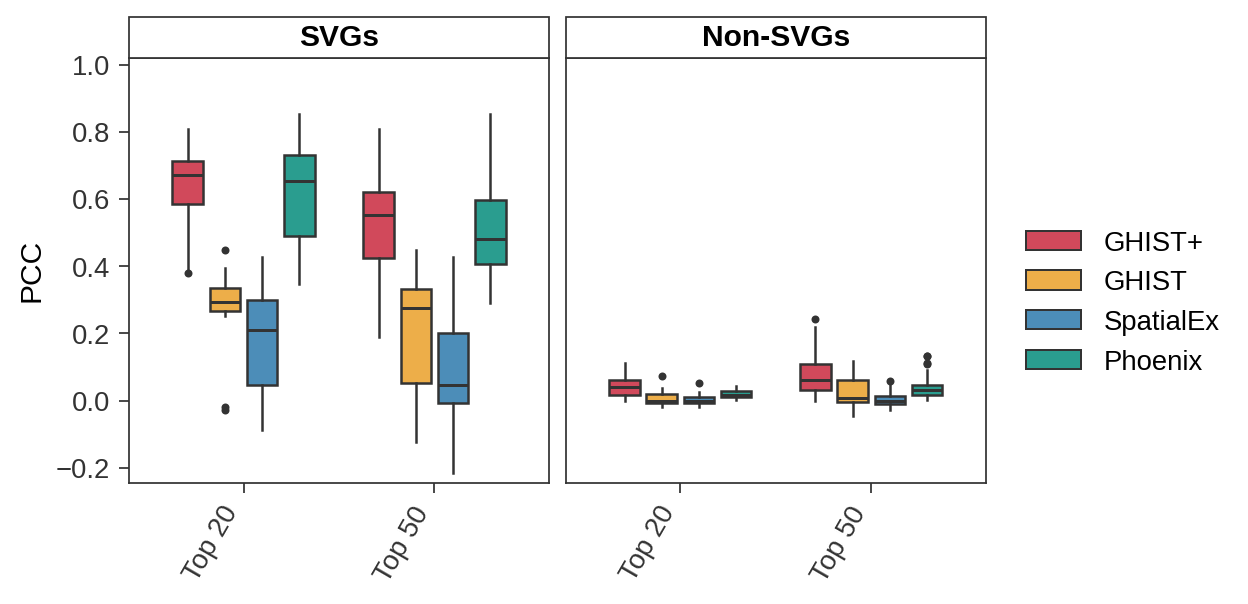

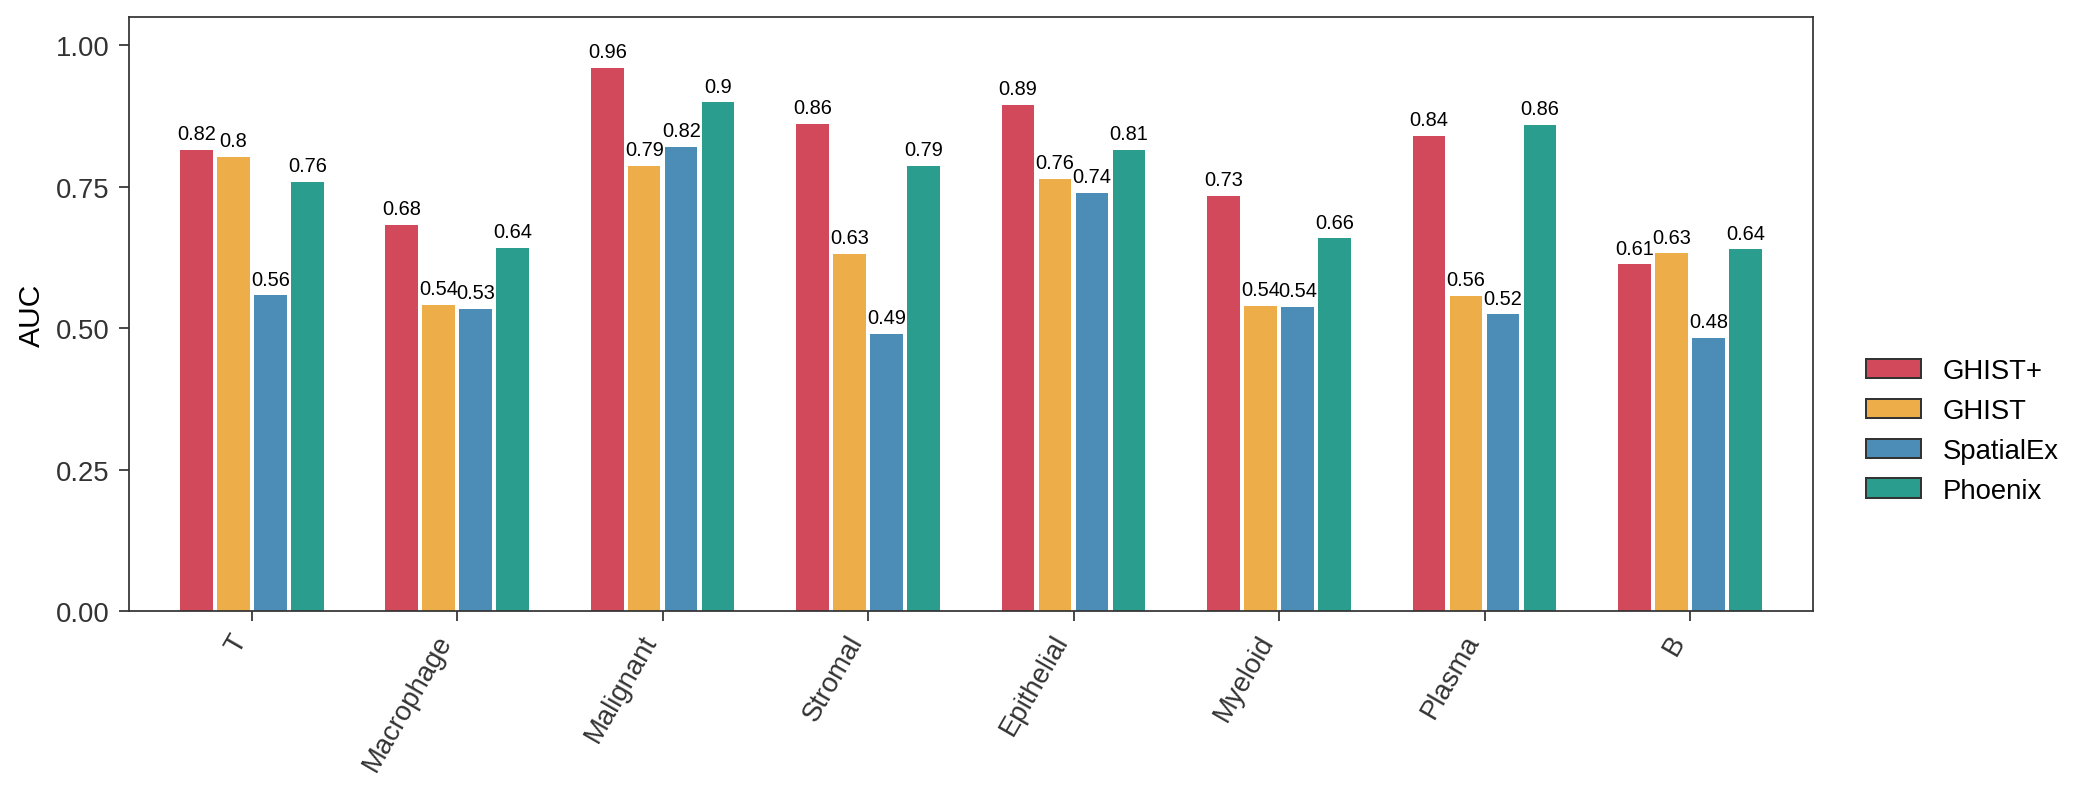

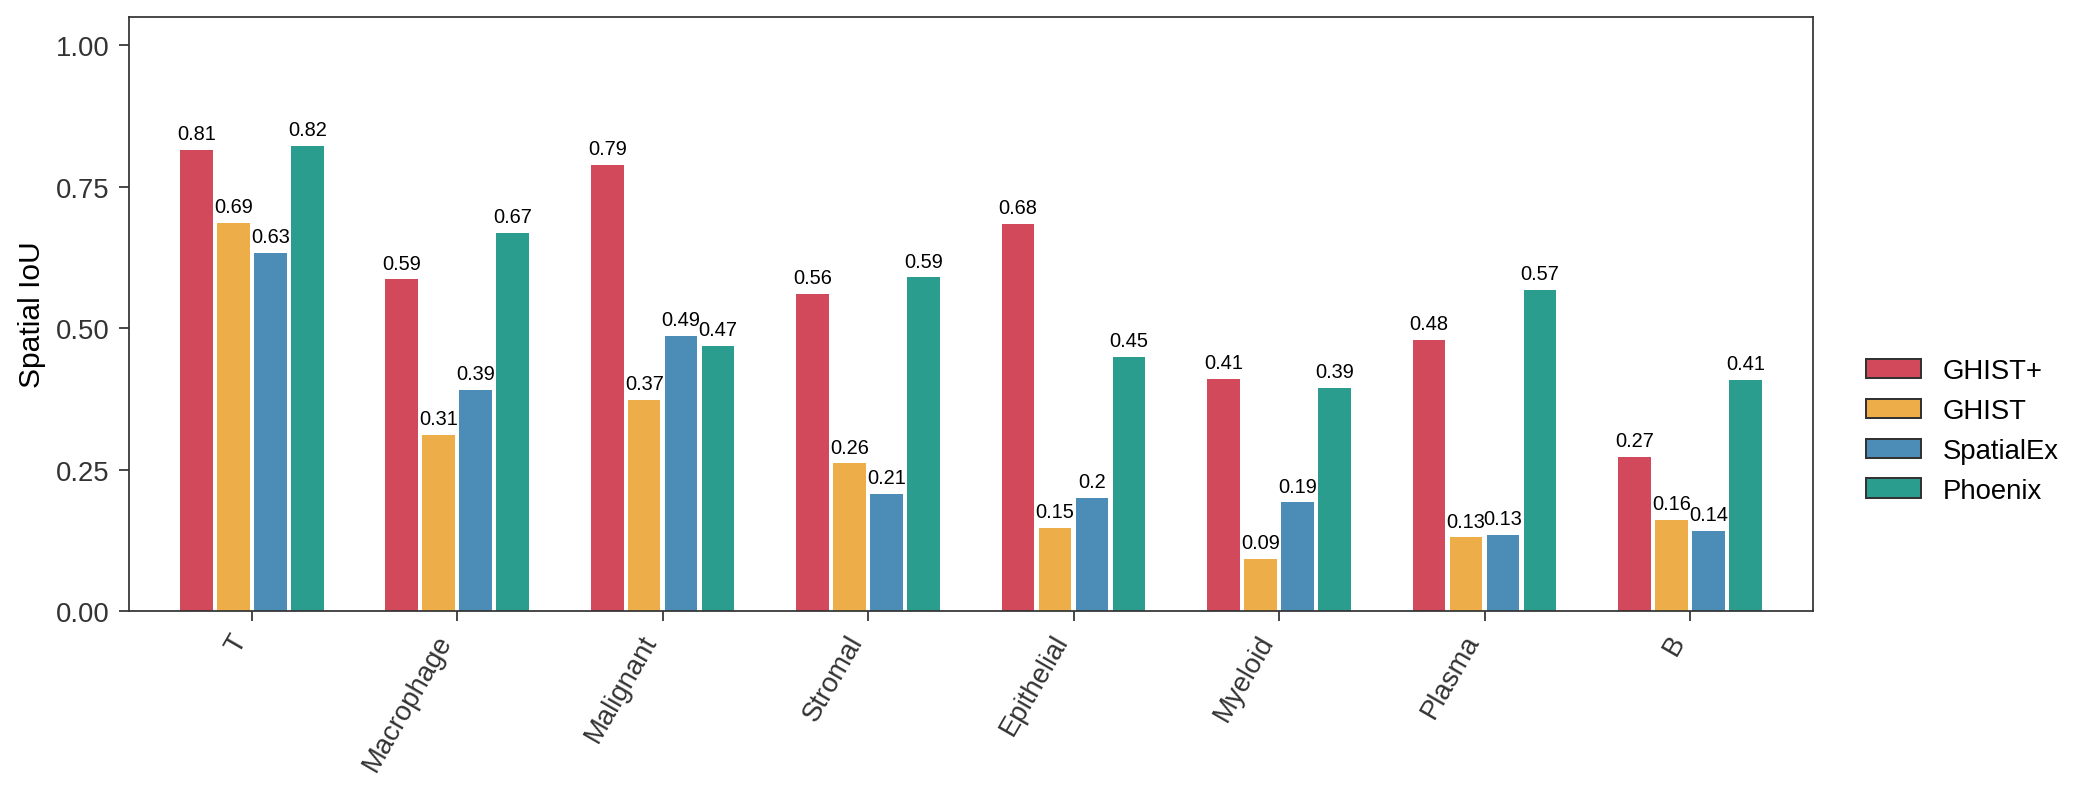

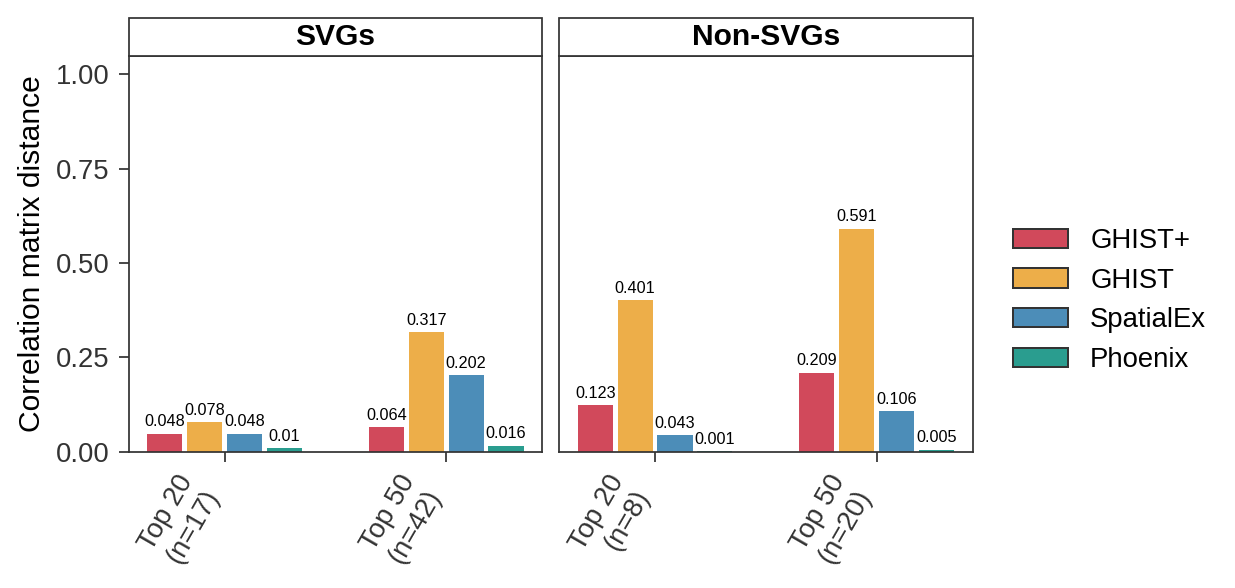

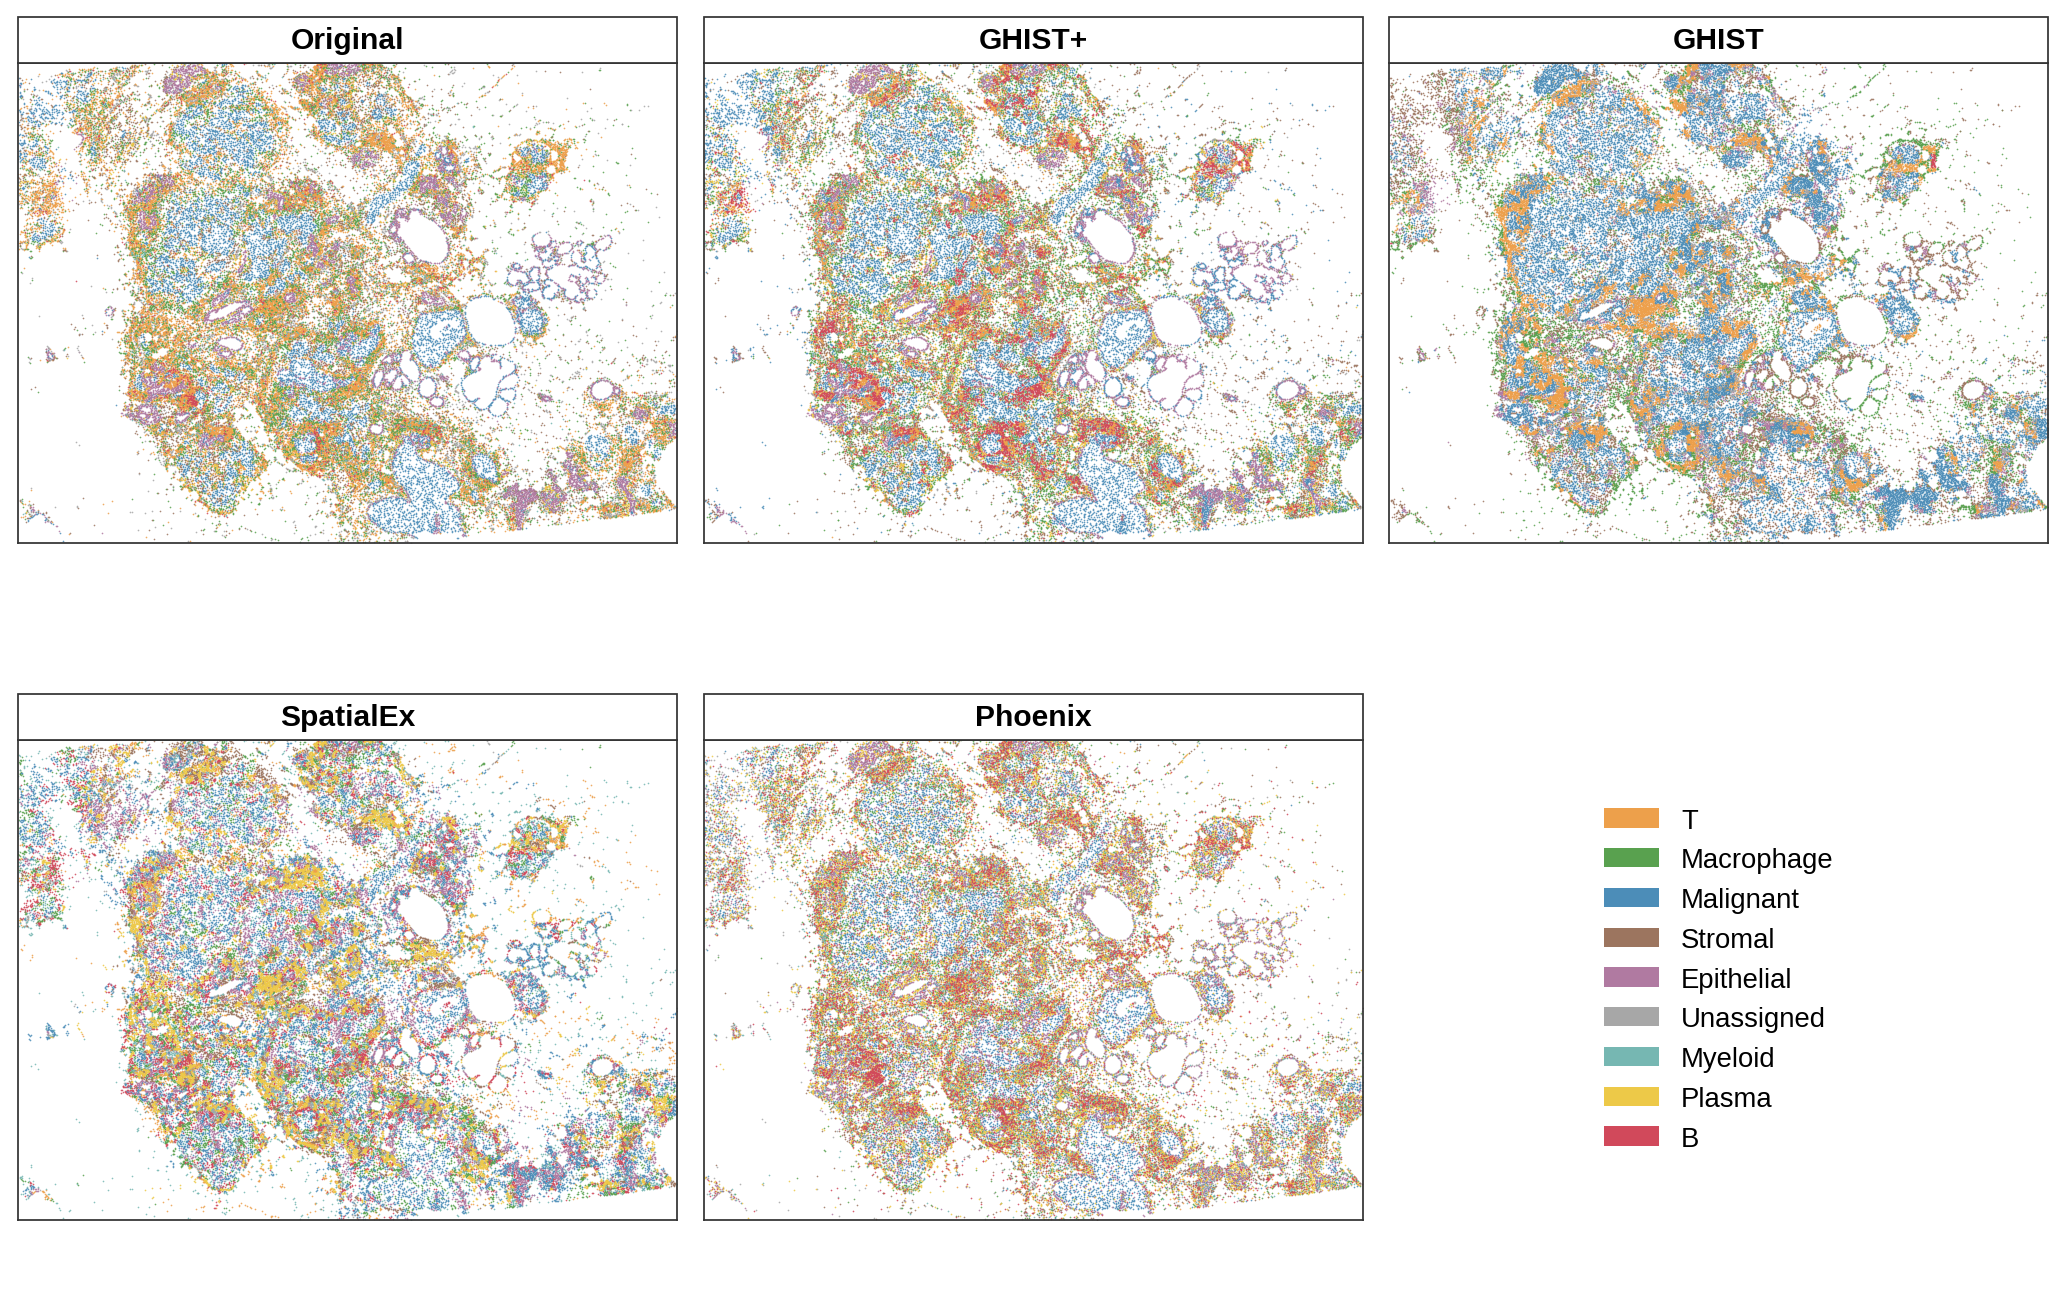

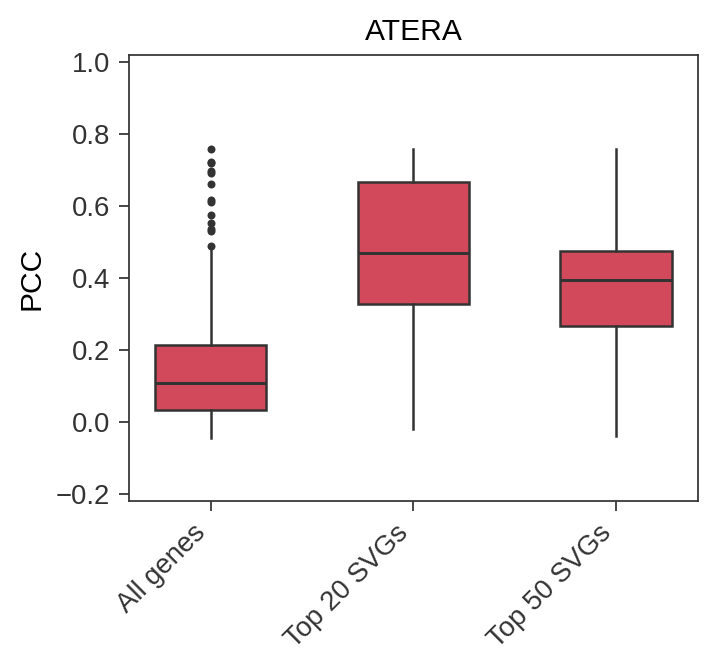

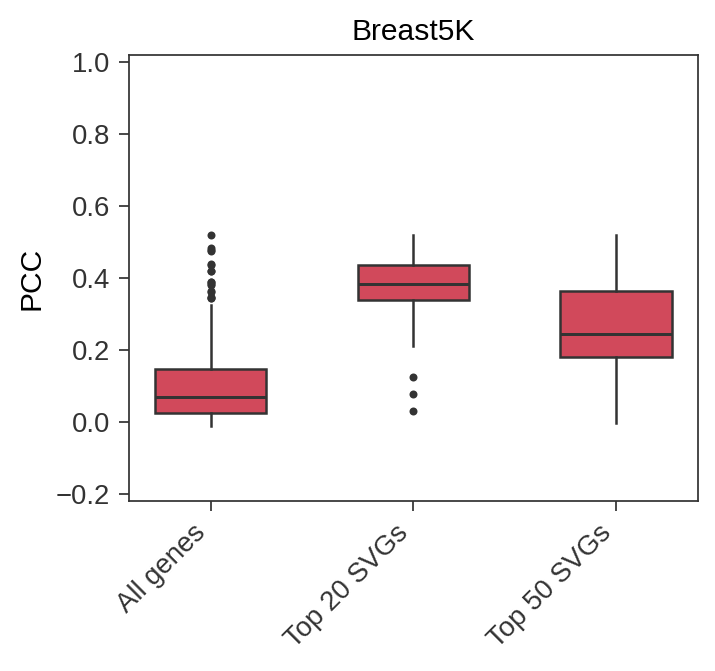

In [6]:
from IPython.display import Image, display

for panel in tables:
    display(Image(filename=str(WORK / f"{panel}.png")))
